# Preliminary Analysis of HARP2 data 

In [1]:
import earthaccess
import xarray as xr
import netCDF4
import os,re,copy,glob
import numpy as np
import matplotlib.pyplot as plt
import pickle 
import cartopy
import sys,os
import cartopy.crs as crs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D
import logging

import warnings
warnings.filterwarnings("ignore")

## Download Data 

In [2]:
auth = earthaccess.login(persist=True)

In [3]:
# results = earthaccess.search_datasets(instrument="oci")
# for item in results:
#     summary = item.summary()
#     print(summary["short-name"])

In [ ]:
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_CLOUD_MASK", 
    # short_name="PACE_OCI_L2_CLOUD",
    # temporal=("2025-07-01", "2025-07-31"),
    temporal=("2025-07-06T19:20:50", "2025-07-06T19:25:49"),
    # granule_name="*L1B*.nc"    # "*L1C*.5km*.nc"
    count=1
)
print(len(results))

In [ ]:
files = earthaccess.download(results, "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_OCI_CLD_PROP")

### Load PACE Utility functions 

In [2]:
import PACE_Util

In [3]:
PACE_data_path_taki = '/umbc/rs/pi_zzbatmos/common/Data/PACE/'
PACE_OCI_L1B_data_path = os.path.join(PACE_data_path_taki,'PACE_OCI_L1B_SCI/')
PACE_OCI_L1C_data_path = os.path.join(PACE_data_path_taki,'PACE_OCI_L1C_SCI/')
PACE_HARP2_L1C_data_path = os.path.join(PACE_data_path_taki,'PACE_HARP2_L1C_SCI/')
PACE_OCI_L2_cloud_data_path = os.path.join(PACE_data_path_taki,'PACE_OCI_CLD_PROP/')

In [4]:
ts='20250706T192050'
H1C= PACE_Util.HARP2_L1(ts,data_level='L1C',data_path = PACE_HARP2_L1C_data_path,spr=True)
oci_l1b_granuel = PACE_Util.OCI_Level1B(ts,data_path=PACE_OCI_L1B_data_path)
oci_l1c_granuel = PACE_Util.OCI_Level1C(ts,data_path=PACE_OCI_L1C_data_path)
oci_l2cld_granuel = PACE_Util.OCI_L2_CLD_NRT(ts,data_path = PACE_OCI_L2_cloud_data_path)

### Plot RGB image based on HARP2 radiance observations

In [ ]:
# to get pixels
plt.figure(figsize=(8,6))
img = plt.imshow(H1C.observation_data.q, cmap='viridis', vmin=3, vmax=15, origin='lower')
plt.title('HARP2 CER', color='k', fontweight='bold')
plt.colorbar(img, extend='both', label='CER', ticks=np.arange(3, 16, 3))
plt.show()

In [5]:
# Find red dot pixel
lat_target = -20.0   # -18   
lon_target = -91.5   # -91.85   

lat = H1C.geolocation_data.latitude   # shape (396, 519)
lon = H1C.geolocation_data.longitude  

# compute squared distance to target
dist = (lat - lat_target)**2 + (lon - lon_target)**2

# find nearest pixel
iy, ix = np.where(dist == np.min(dist))

print("Red dot pixel HARP2:", ix[0], iy[0])

Red dot pixel HARP2: 289 188


In [ ]:
# H1C.observation_data.q.shape
# help(H1C.plot_true_color_RGB)

In [6]:
# H1C.plot_true_color_RGB(figsize=[8, 6], x0_indices=[292], y0_indices=[231])

## Compare two pixels

In [5]:
HARP2_L1C_clean= '20250706T192050' # closed cloud case

HARP2_L1C_ACA= '20250706T192050' # open cloud case

H1C_clean= PACE_Util.HARP2_L1(HARP2_L1C_clean, data_level='L1C',data_path = PACE_HARP2_L1C_data_path, spr=True)
H1C_ACA=   PACE_Util.HARP2_L1(HARP2_L1C_ACA, data_level='L1C',data_path = PACE_HARP2_L1C_data_path, spr=True)

In [6]:
x0_clean, y0_clean = 292, 231 
# x0_clean, y0_clean = 289, 188 
# x0_clean, y0_clean = 304, 207
# x0_ACA, y0_ACA = 289, 188

### Plot the RGB image of the two cases

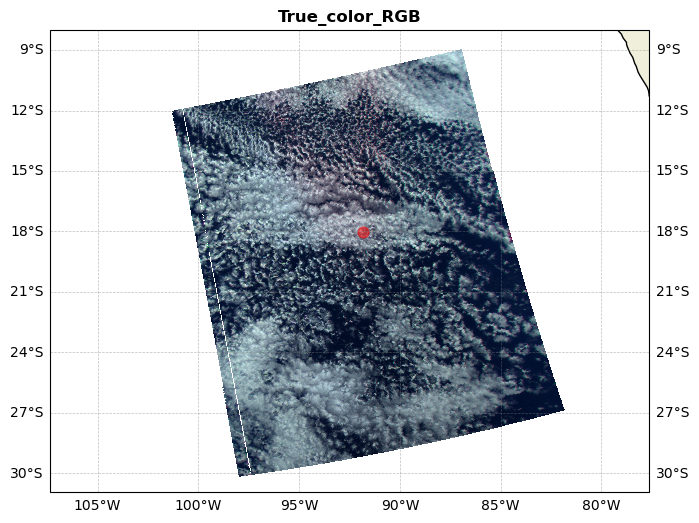

In [7]:
H1C_clean.plot_true_color_RGB(figsize=[8, 6], x0_indices=[x0_clean], y0_indices=[y0_clean], save_RGB=False)

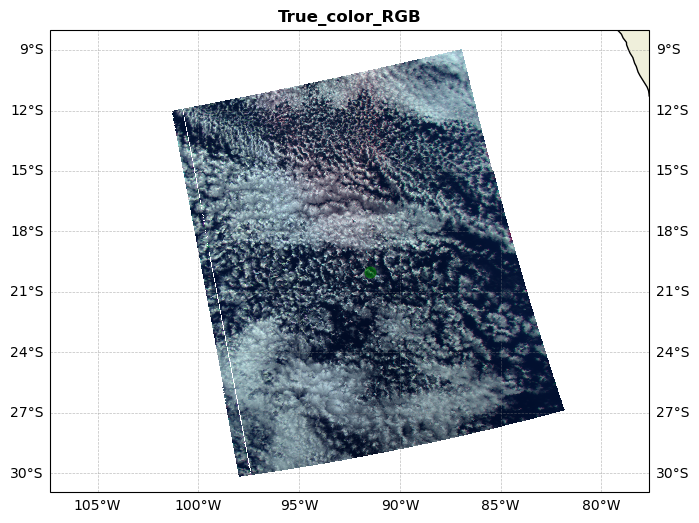

In [13]:
H1C_ACA.plot_true_color_RGB(figsize=[8, 6], x0_indices=[x0_ACA], y0_indices=[y0_ACA], colors='g')

1 10
[664.564]


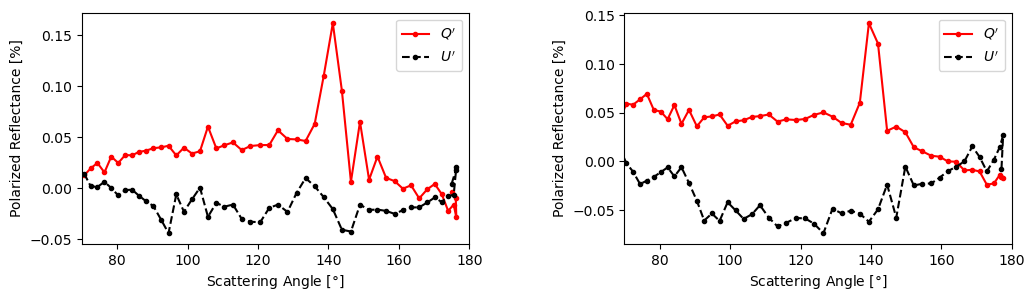

In [14]:
angle_range=[0,10,60,80,90]
color_index = ['b','g','r','tab:purple']

fig,ax=plt.subplots(1,2,figsize=(12,3))
fig.subplots_adjust(wspace=0.4)

ax[0].set_xlim([70,180])
ax[1].set_xlim([70,180])

ax[0].set_xlabel(r'Scattering Angle [$\degree$]')
ax[0].set_ylabel(r'Polarized Reflectance [%]')
ax[1].set_xlabel(r'Scattering Angle [$\degree$]')
ax[1].set_ylabel(r'Polarized Reflectance [%]')

for ia in range(1,2):
    print(ia,angle_range[ia])
    al = angle_range[ia]
    ar = angle_range[ia+1]
    print(H1C_clean.sensors_views_bands.intensity_wavelength[al].values)
    label_text=('{0:5.2f} nm'.format(H1C_clean.sensors_views_bands.intensity_wavelength[al].values[0]))
    ax[0].plot(H1C_clean.geolocation_data.scattering_angle[y0_clean,x0_clean,al:ar], 
               H1C_clean.q_s_norm[y0_clean,x0_clean,al:ar], label=r"$Q'$", c='r', marker='.', markersize=6)
    ax[0].plot(H1C_clean.geolocation_data.scattering_angle[y0_clean,x0_clean,al:ar], 
               H1C_clean.u_s_norm[y0_clean,x0_clean,al:ar], label=r"$U'$", c='k',marker='.', 
               markersize=6, ls='dashed')
    
    ax[1].plot(H1C_ACA.geolocation_data.scattering_angle[y0_ACA,x0_ACA,al:ar], 
               H1C_ACA.q_s_norm[y0_ACA,x0_ACA,al:ar], label=r"$Q'$", c='r', marker='.', markersize=6)
    ax[1].plot(H1C_ACA.geolocation_data.scattering_angle[y0_ACA,x0_ACA,al:ar], 
               H1C_ACA.u_s_norm[y0_ACA,x0_ACA,al:ar], label=r"$U'$", c='k', marker='.', 
               markersize=6, ls='dashed')

ax[0].legend(loc=0)
ax[1].legend(loc=0)

## Load Polarized Scattering Phase Functions of water droplets for re and ve retrievals

In [7]:
class Water_Cloud_LUT():
    def __init__(self,LUT_nc_filename,LUT_par_list):
        ncf = netCDF4.Dataset(LUT_nc_filename,'r')
        self.LUT_par_dict={}
        for par in LUT_par_list:
            print('reading',par)
            self.LUT_par_dict[par]=np.array(ncf.variables[par])
            
LUT_ncfile='/umbc/rs/pi_zzbatmos/common/Data/Polarized_Droplet_Single_Scattering_Properties_for_PARASOL.nc'
LUT_par_list=['band_center', 're','veff','scattering_angle','P11','P12']
WC_LUT=Water_Cloud_LUT(LUT_ncfile, LUT_par_list)

reading band_center
reading re
reading veff
reading scattering_angle
reading P11
reading P12


In [8]:
for k in WC_LUT.LUT_par_dict.keys():
    print(k,WC_LUT.LUT_par_dict[k].shape,WC_LUT.LUT_par_dict[k].min(),WC_LUT.LUT_par_dict[k].max())

band_center (4,) 0.443 0.865
re (197,) 1.0 50.0
veff (11,) 0.01 0.10999999
scattering_angle (1801,) 0.0 180.0
P11 (4, 11, 197, 1801) 0.012604483 236919.72
P12 (4, 11, 197, 1801) -3.349194 5.455567


In [9]:
print(WC_LUT.LUT_par_dict['band_center'])

[0.443 0.49  0.67  0.865]


In [ ]:
print(WC_LUT.LUT_par_dict['re'])

In [ ]:
print(WC_LUT.LUT_par_dict['veff'])

In [10]:
iwl=2
ire=np.searchsorted(WC_LUT.LUT_par_dict['re'],[5,15,30])
ive=np.searchsorted(WC_LUT.LUT_par_dict['veff'],[0.01,0.05,0.1])
print(ire)
print(ive)

[ 16  56 116]
[ 1  5 10]


Text(122, 0.52, 'b)')

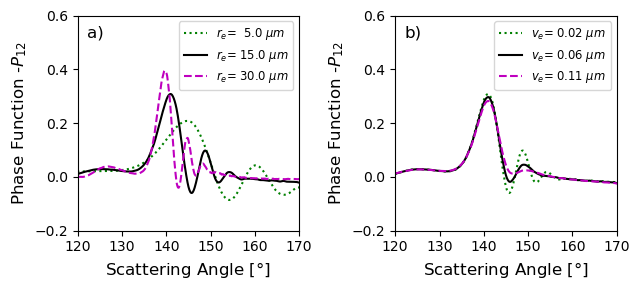

In [11]:
fig,ax=plt.subplots(1,2,figsize=[6.5,3],tight_layout=True)
ls=['dotted','solid','dashed']
color=['g','k','m']
n=0
for i in ire:
    ax[0].plot(WC_LUT.LUT_par_dict['scattering_angle'], -WC_LUT.LUT_par_dict['P12'][iwl,ive[0],i,:],
               ls=ls[n],c=color[n],label=r'$r_e$={0:5.1f} $\mu m$'.format(WC_LUT.LUT_par_dict['re'][i]))
    n+=1
n=0
for j in ive:
    ax[1].plot(WC_LUT.LUT_par_dict['scattering_angle'], -WC_LUT.LUT_par_dict['P12'][iwl,j,ire[1],:],
               ls=ls[n],c=color[n],label=r'$v_e$={0:5.2f} $\mu m$'.format(WC_LUT.LUT_par_dict['veff'][j]))  
    n+=1
for axis in ax:
    axis.legend(loc=0,ncol=1,fontsize='small')
    axis.set_xlim([120,170])
    axis.set_ylim([-0.2,0.6])
    axis.set_xlabel(r'Scattering Angle [$\degree$]',fontsize='large')
    axis.set_ylabel(r'Phase Function -$P_{12}$',fontsize='large')
ax[0].text(122,0.52,'a)',fontsize='large')
ax[1].text(122,0.52,'b)',fontsize='large')
# fig.savefig('HARP_CER_CER_retrieval_illustration.png', dpi=500, bbox_inches="tight")

In [12]:
# This algorithm fits observed polarized reflectance to precomputed polarized phase functions LUT
def Rp_mod(x,a,b,c):
    sca=x[0,:]
    P12=x[1,:]
    #y=a*P12+b*np.cos(np.deg2rad(sca))**2+c
    y=a*P12+b*sca+c
    return y

def Qual_index(P12,Robs,Rfit):
    P12_var = np.mean(P12**2)-np.mean(P12)**2
    RMS = np.mean((Robs-Rfit)**2)
    return P12_var/ RMS

re best fit 13.75
ve best fit 0.01


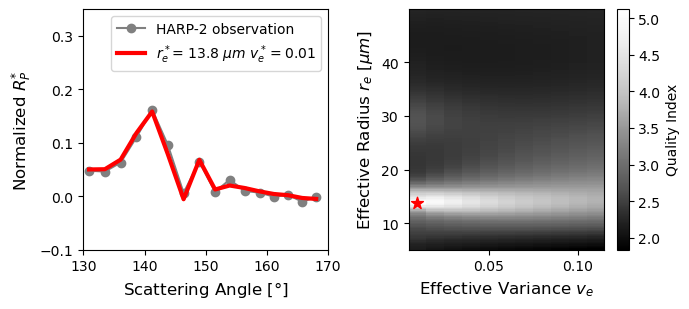

In [13]:
al,ar=10,60
bd_index = 2
sca_range = [130,170]
sca_range_index = (H1C_clean.geolocation_data.scattering_angle[y0_clean,x0_clean,al:ar] > sca_range[0]) &\
                  (H1C_clean.geolocation_data.scattering_angle[y0_clean,x0_clean,al:ar] < sca_range[1])  
Sca_obs = H1C_clean.geolocation_data.scattering_angle[y0_clean,x0_clean,al:ar][sca_range_index]
Rp_obs = H1C_clean.q_s_norm[y0_clean,x0_clean,al:ar][sca_range_index]
Sca_lut = WC_LUT.LUT_par_dict['scattering_angle']

Nre,Nve = WC_LUT.LUT_par_dict['re'].size,WC_LUT.LUT_par_dict['veff'].size

fig, ax = plt.subplots(1, 2, figsize=(7,3.2), tight_layout=True)
ax[0].set_xlim(sca_range)
ax[0].set_ylim([-0.1,0.35])
ax[0].plot(Sca_obs, Rp_obs, marker='o', c='gray', label='HARP-2 observation')

fitting_qual=np.zeros([Nre,Nve])
fitting_par=np.zeros([Nre,Nve,3])

# Loop over all (re, ve) to find best match
for re_index in range(0,Nre):
    for ve_index in range(0,Nve):
        p12_lut   = np.interp(Sca_obs,Sca_lut,WC_LUT.LUT_par_dict['P12'][bd_index,ve_index,re_index,:])
        predictor = np.stack((Sca_obs,p12_lut))
        popt, pcov = curve_fit(Rp_mod, predictor, Rp_obs, p0=[-1,-1,0])
        Rp_fit=Rp_mod(predictor,*popt)
        
        fitting_qual[re_index,ve_index]=Qual_index(p12_lut,Rp_obs,Rp_fit)
        fitting_par[re_index,ve_index,:]=popt
Qual=fitting_qual
best_fit_re_index,  best_fit_ve_index =np.unravel_index(fitting_qual.argmax(),fitting_qual.shape)

re_best_fit=WC_LUT.LUT_par_dict['re'][best_fit_re_index]
ve_best_fit=WC_LUT.LUT_par_dict['veff'][best_fit_ve_index] 
print('re best fit',re_best_fit)
print('ve best fit',ve_best_fit)

p12_best_fit= np.interp(Sca_obs,Sca_lut,WC_LUT.LUT_par_dict['P12'][bd_index,best_fit_ve_index,best_fit_re_index,:])
Qual_best_fit = fitting_qual[best_fit_re_index, best_fit_ve_index]
par_best_fit = fitting_par[best_fit_re_index, best_fit_ve_index,:]
predictor_best_fit = np.stack((Sca_obs, p12_best_fit))
a,b,c = par_best_fit

ax[0].plot(Sca_obs, Rp_mod(predictor_best_fit,a,b,c), c='r',
           label=r'$r_e^*$={0:5.1f} $\mu m$ $v_e^*={1:5.2}$'.format(re_best_fit,ve_best_fit), ls='solid', lw=3.0)
ax[0].set_xlabel(r'Scattering Angle [$\degree$]',fontsize='large')
ax[0].set_ylabel(r'Normalized $R^{*}_P$',fontsize='large')
ax[0].legend(loc='upper right')

ve, re= WC_LUT.LUT_par_dict['veff'], WC_LUT.LUT_par_dict['re']
re_index= (5<re) & (re<50)

cf=ax[1].pcolormesh(ve, re[re_index], np.log(Qual[re_index,:]), cmap='Greys_r')
ax[1].scatter(ve_best_fit, re_best_fit, c='r', marker='*', s=80)
cbar=plt.colorbar(cf,ax=ax[1])
cbar.set_label('Quality Index')
ax[1].set_xlabel(r'Effective Variance $v_e$',fontsize='large')
ax[1].set_ylabel(r'Effective Radius $r_e$ $[\mu m]$',fontsize='large')

plt.tight_layout()
# plt.savefig('HARP2_cloud_microphysics_example_retrieval.png', dpi=500, bbox_inches="tight")
plt.show()

re best fit: 13.75
ve best fit: 0.01


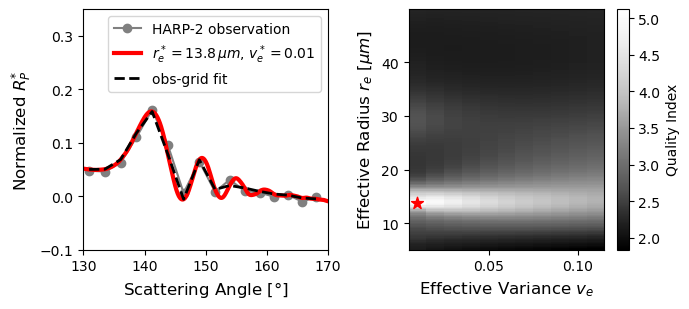

In [14]:
al, ar = 10, 60
bd_index = 2
sca_range = [130, 170]
sca_range_index = (H1C_clean.geolocation_data.scattering_angle[y0_clean, x0_clean, al:ar] > sca_range[0]) &\
                  (H1C_clean.geolocation_data.scattering_angle[y0_clean, x0_clean, al:ar] < sca_range[1])

Sca_obs = H1C_clean.geolocation_data.scattering_angle[y0_clean, x0_clean, al:ar][sca_range_index]
Rp_obs = H1C_clean.q_s_norm[y0_clean, x0_clean, al:ar][sca_range_index]
Sca_lut = WC_LUT.LUT_par_dict['scattering_angle']

Nre, Nve = WC_LUT.LUT_par_dict['re'].size, WC_LUT.LUT_par_dict['veff'].size

fig, ax = plt.subplots(1, 2, figsize=(7,3.2), tight_layout=True)
ax[0].set_xlim(sca_range)
ax[0].set_ylim([-0.1, 0.35])
ax[0].plot(Sca_obs, Rp_obs, marker='o', c='gray', label='HARP-2 observation')

# Fitting loop
fitting_qual = np.zeros([Nre, Nve])
fitting_par = np.zeros([Nre, Nve, 3])

for re_index in range(Nre):
    for ve_index in range(Nve):
        # interpolate phase function from LUT to observation angular grid
        p12_lut = np.interp(Sca_obs, Sca_lut, WC_LUT.LUT_par_dict['P12'][bd_index, ve_index, re_index, :])
        predictor = np.stack((Sca_obs, p12_lut))
        try:
            popt, pcov = curve_fit(Rp_mod, predictor, Rp_obs, p0=[-1,-1,0])
        except Exception:
            popt = np.array([np.nan,np.nan,np.nan])

        Rp_fit = Rp_mod(predictor, *popt)
        fitting_qual[re_index, ve_index] = Qual_index(p12_lut, Rp_obs, Rp_fit)
        fitting_par[re_index, ve_index, :] = popt

Qual = fitting_qual
best_fit_re_index, best_fit_ve_index = np.unravel_index(np.nanargmax(fitting_qual), fitting_qual.shape)

re_best_fit = WC_LUT.LUT_par_dict['re'][best_fit_re_index]
ve_best_fit = WC_LUT.LUT_par_dict['veff'][best_fit_ve_index]
print('re best fit:', re_best_fit)
print('ve best fit:', ve_best_fit)

# Best fit parameters
Qual_best_fit = fitting_qual[best_fit_re_index, best_fit_ve_index]
par_best_fit = fitting_par[best_fit_re_index, best_fit_ve_index, :]
a, b, c = par_best_fit

# Optional: Observation grid fit (coarse res)
p12_best_fit=np.interp(Sca_obs,Sca_lut,WC_LUT.LUT_par_dict['P12'][bd_index, best_fit_ve_index,best_fit_re_index,:])
predictor_best_fit = np.stack((Sca_obs, p12_best_fit))
Rp_obsgrid_fit = Rp_mod(predictor_best_fit, a, b, c)

# fit on HIGH-RES LUT grid (to preserve bow structure)
Sca_highres = WC_LUT.LUT_par_dict['scattering_angle']
p12_highres = WC_LUT.LUT_par_dict['P12'][bd_index, best_fit_ve_index, best_fit_re_index, :]
predictor_highres = np.stack((Sca_highres, p12_highres))
Rp_highres_fit = Rp_mod(predictor_highres, a, b, c)

ax[0].plot(Sca_highres, Rp_highres_fit, c='r', lw=3.0, ls='solid', 
           label=rf'$r_e^*={re_best_fit:5.1f}\,\mu m$, $v_e^*={ve_best_fit:5.2f}$')
ax[0].plot(Sca_obs, Rp_obsgrid_fit, c='k', lw=2.0, ls='dashed', label='obs-grid fit')
ax[0].set_xlabel(r'Scattering Angle [$\degree$]', fontsize='large')
ax[0].set_ylabel(r'Normalized $R^{*}_P$', fontsize='large')
ax[0].legend(loc='upper right')

# Quality Index plot
ve = WC_LUT.LUT_par_dict['veff']
re = WC_LUT.LUT_par_dict['re']
re_index = (re > 5) & (re < 50)

cf=ax[1].pcolormesh(ve, re[re_index], np.log(Qual[re_index,:]), cmap='Greys_r')
ax[1].scatter(ve_best_fit, re_best_fit, c='r', marker='*', s=80)
cbar=plt.colorbar(cf, ax=ax[1])
cbar.set_label('Quality Index')
ax[1].set_xlabel(r'Effective Variance $v_e$', fontsize='large')
ax[1].set_ylabel(r'Effective Radius $r_e$ $[\mu m]$',fontsize='large')

plt.tight_layout()
# plt.savefig('HARP2_cloud_microphysics_retrieval2.png', dpi=500, bbox_inches="tight")
plt.show()

## Interpolating to High Res (LUT) and using as New Observation 

Sca_obs min, max: 130.92999267578125 168.0399932861328
Sca_newobs min, max: 131.0 168.0

re retrieved: 14.0
ve retrieved: 0.02


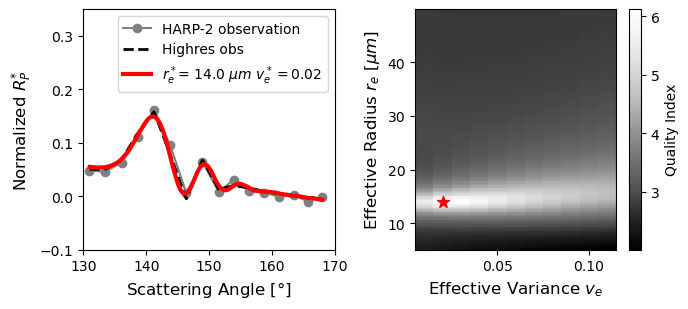

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(7,3.2), tight_layout=True)       # (8, 3.5)

ax[0].set_xlim([130,170])
ax[0].set_ylim([-0.1, 0.35])
ax[0].plot(Sca_obs, Rp_obs, marker='o', c='gray', label='HARP-2 observation')
print('Sca_obs min, max:', float(Sca_obs.min()), float(Sca_obs.max()))

# interpolate to High Res
Rp_lut= np.interp(Sca_lut, Sca_obs, Rp_obsgrid_fit)    

# New observation
sca_range_index = (Sca_lut>=float(Sca_obs.min())) & (Sca_lut<=float(Sca_obs.max())) 
Sca_newobs = Sca_lut[sca_range_index]
Rp_newobs  = Rp_lut[sca_range_index] 

ax[0].plot(Sca_newobs, Rp_newobs, c='k', lw=2.0, ls='dashed', label='Highres obs')
print('Sca_newobs min, max:', Sca_newobs.min(), Sca_newobs.max())

fitting_qual_new = np.zeros([Nre, Nve])
fitting_par_new  = np.zeros([Nre, Nve, 3])
for re_index in range(Nre):      # Loop over all (re, ve) to find best match
    for ve_index in range(Nve):      
        p12_new = np.interp(Sca_newobs, Sca_lut, WC_LUT.LUT_par_dict['P12'][bd_index, ve_index, re_index, :])
        predictor_new = np.stack((Sca_newobs, p12_new))
        try:
            popt_new, _ = curve_fit(Rp_mod, predictor_new, Rp_newobs, p0=[-1, -1, 0])
        except Exception:
            popt_new = np.array([np.nan, np.nan, np.nan])

        Rp_fit_new = Rp_mod(predictor_new, *popt_new)
        fitting_qual_new[re_index, ve_index] = Qual_index(p12_new, Rp_newobs, Rp_fit_new)
        fitting_par_new[re_index, ve_index, :] = popt_new
        
Qual = fitting_qual_new
best_re_new, best_ve_new = np.unravel_index(np.nanargmax(fitting_qual_new), fitting_qual_new.shape)

re_best_fit_new = WC_LUT.LUT_par_dict['re'][best_re_new]
ve_best_fit_new = WC_LUT.LUT_par_dict['veff'][best_ve_new]
print("")
print("re retrieved:", re_best_fit_new)
print("ve retrieved:", ve_best_fit_new)

Qual_best_fit_new = fitting_qual_new[best_re_new, best_ve_new]
par_best_fit_new = fitting_par_new[best_re_new, best_ve_new, :]
a, b, c = par_best_fit_new

p12_best_fit_new= np.interp(Sca_newobs,Sca_lut,WC_LUT.LUT_par_dict['P12'][bd_index,best_ve_new,best_re_new,:])
predictor_best_fit_new = np.stack((Sca_newobs, p12_best_fit_new))

ax[0].plot(Sca_newobs, Rp_mod(predictor_best_fit_new,a,b,c), c='r',
           label=r'$r_e^*$={0:5.1f} $\mu m$ $v_e^*={1:5.2}$'.format(re_best_fit_new,ve_best_fit_new), ls='solid', lw=3.0)
ax[0].set_xlabel(r'Scattering Angle [$\degree$]', fontsize='large')
ax[0].set_ylabel(r'Normalized $R^{*}_P$', fontsize='large')
ax[0].legend(loc='upper right')

# Quality Index plot
ve = WC_LUT.LUT_par_dict['veff']
re = WC_LUT.LUT_par_dict['re']
re_index = (re > 5) & (re < 50)

cf=ax[1].pcolormesh(ve, re[re_index], np.log(Qual[re_index,:]), cmap='Greys_r')
ax[1].scatter(ve_best_fit_new, re_best_fit_new, c='r', marker='*', s=80)
cbar=plt.colorbar(cf, ax=ax[1])
cbar.set_label('Quality Index')
ax[1].set_xlabel(r'Effective Variance $v_e$', fontsize='large')
ax[1].set_ylabel(r'Effective Radius $r_e$ $[\mu m]$',fontsize='large')

plt.tight_layout()
# plt.savefig('HARP2_cloud_microphysics_retrieval2.png', dpi=500, bbox_inches="tight")
plt.show()

## Monte-Carlo Simulation to perturb retrieval uncertainty

re [μm]: mean=18.758, median=18.750, std=0.691, 16th=18.000, 84th=19.500
ve: mean=0.100, median=0.100, std=0.007, 16th=0.090, 84th=0.110

Final uncertainty estimate (from MC):
re = 18.75 (+0.75/-0.75) μm (±1SD)
ve = 0.100 (+0.010/-0.010) (±1SD)


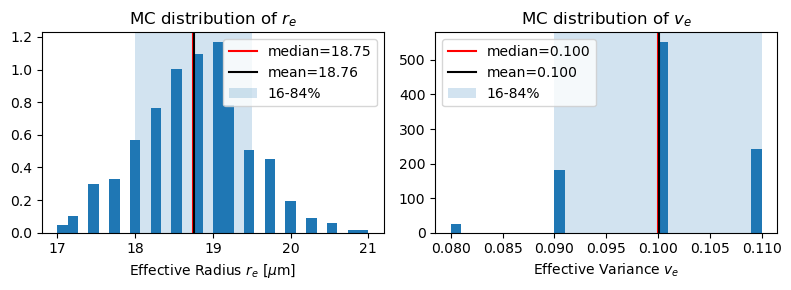

In [14]:
# Monte Carlo Simulation
n_mc = 500                  # number of Monte Carlo realizations
harp_uncertainty = 0.03      # 3% fractional uncertainty
random_seed = 42
np.random.seed(random_seed)

# Pre-allocate arrays to store best-fit parameters from each realization
mc_re_best = np.zeros(n_mc)
mc_ve_best = np.zeros(n_mc)
mc_pbest = np.zeros((n_mc,3))   # store fit parameters a,b,c 

# Using LUT grid scanning approach to find best (re, ve) for each perturbed observation.
for i in range(n_mc):
    # perturb Rp_obs according to fractional uncertainty (gaussian)
    noise = np.random.normal(loc=0.0, scale=harp_uncertainty, size=Rp_obs.shape)
    Rp_pert = Rp_obs * (1.0 + noise)

    # Arrays to collect quality and params for this realization
    fitting_qual_mc = np.zeros_like(fitting_qual)   # same shape [Nre, Nve]
    fitting_par_mc = np.zeros_like(fitting_par)     # same shape [Nre, Nve, 3]
    for re_index in range(Nre):
        for ve_index in range(Nve):
            p12_lut = np.interp(Sca_obs, Sca_lut, WC_LUT.LUT_par_dict['P12'][bd_index, ve_index, re_index, :])
            predictor = np.stack((Sca_obs, p12_lut))
            try:
                popt, pcov = curve_fit(Rp_mod, predictor, Rp_pert, p0=[-1, -1, 0], maxfev=2000)
            except Exception:
                popt = np.array([np.nan, np.nan, np.nan])
            Rp_fit = Rp_mod(predictor, *popt)
            fitting_qual_mc[re_index, ve_index] = Qual_index(p12_lut, Rp_pert, Rp_fit)
            fitting_par_mc[re_index, ve_index, :] = popt

    # find best indices for this realization
    best_idx = np.unravel_index(np.nanargmax(fitting_qual_mc), fitting_qual_mc.shape)
    best_re_idx, best_ve_idx = best_idx
    mc_re_best[i] = WC_LUT.LUT_par_dict['re'][best_re_idx]
    mc_ve_best[i] = WC_LUT.LUT_par_dict['veff'][best_ve_idx]
    mc_pbest[i, :] = fitting_par_mc[best_re_idx, best_ve_idx, :]

# Compute statistics
def summarize_samples(samples, name):
    mean = np.nanmean(samples)
    med = np.nanmedian(samples)
    std = np.nanstd(samples, ddof=1)
    p16, p84 = np.nanpercentile(samples, [16, 84])
    print(f"{name}: mean={mean:.3f}, median={med:.3f}, std={std:.3f}, 16th={p16:.3f}, 84th={p84:.3f}")
    return {"mean": mean, "median": med, "std": std, "p16": p16, "p84": p84}

re_stats = summarize_samples(mc_re_best, "re [μm]")
ve_stats = summarize_samples(mc_ve_best, "ve")

# Plot histograms of MC results
fig2, ax = plt.subplots(1,2, figsize=(8,3), tight_layout=True)

ax[0].hist(mc_re_best, bins=30, density=True)
ax[0].axvline(re_stats['median'], color='r', linestyle='-', label=f"median={re_stats['median']:.2f}")
ax[0].axvline(re_stats['mean'], color='k', linestyle='-', label=f"mean={re_stats['mean']:.2f}")
ax[0].axvspan(re_stats['p16'], re_stats['p84'], alpha=0.2, label='16-84%')
ax[0].set_xlabel(r'Effective Radius $r_e$ [$\mu$m]')
ax[0].set_title('MC distribution of $r_e$')
ax[0].legend()

ax[1].hist(mc_ve_best, bins=30, density=True)
ax[1].axvline(ve_stats['median'], color='r', linestyle='-', label=f"median={ve_stats['median']:.3f}")
ax[1].axvline(ve_stats['mean'], color='k', linestyle='-', label=f"mean={ve_stats['mean']:.3f}")
ax[1].axvspan(ve_stats['p16'], ve_stats['p84'], alpha=0.2, label='16-84%')
ax[1].set_xlabel(r'Effective Variance $v_e$')
ax[1].set_title('MC distribution of $v_e$')
ax[1].legend()

# Print final result
print("\nFinal uncertainty estimate (from MC):")
print(f"re = {re_stats['median']:.2f} (+{re_stats['p84']-re_stats['median']:.2f}/-{re_stats['median']-re_stats['p16']:.2f}) μm (±1SD)")
print(f"ve = {ve_stats['median']:.3f} (+{ve_stats['p84']-ve_stats['median']:.3f}/-{ve_stats['median']-ve_stats['p16']:.3f}) (±1SD)")
plt.show()